# Simulation: Approximating a Linear Model

The goal of this simulation is to demonstrate the rate of decay of a
linear model’s mean-squared error as more and more parameters are
randomly chosen to be included in the model. First, load some packages:

In [1]:
using CausalTables
using Random
using StatsBase
using Distributions
using LinearAlgebra
using Plots
using GLM
using Tables
using LaTeXStrings

using Logging
disable_logging(Logging.Info)
disable_logging(Logging.Warn)

Random.seed!(1234)

TaskLocalRNG()

## Experiment 1: Uncorrelated Covariates

We expect this simulation to be a “worst-case-scenario” that comes close
to the theoretical error bound for uniformly random approximations. Let
us simulate some data and fit a ground-truth model.


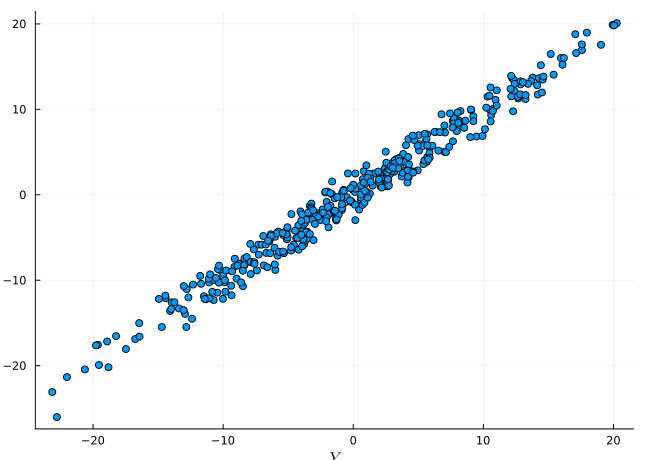

In [1]:
d = 100
β = collect(1:d) ./ d
Σ = 2 .*  diagm(ones(d))# .+ ones(d,d)
dgp(Σ) = @dgp(
    LN ~ MvNormal(Σ),
    Y ~ Cosine.(LN * β, 4)
)
scm(Σ) = StructuralCausalModel(dgp(Σ), [], :Y)

n = 400
ct = rand(scm(Σ), n)
mat = Tables.matrix(ct)
X = mat[:, 1:end-1]
y = mat[:, end]

# Ground truth
X_design = hcat(ones(n), X)
model = lm(X_design, y)
yhat = GLM.predict(model, X_design)

Plots.scatter(y, yhat, legend = false, xlabel = L"Y", ylabel = L"\hat{Y}")

Next, we set up the experiment: simulate a series of approximations with
an increasing subset of covariates chosen uniformly at random.

In [1]:
mse(yhat, y) = mean((y .- yhat).^2)

function draw_approx(X, y, m; replace=false)
    Xm = X[:, sample(1:size(X, 2), m, replace=replace)]
    Xm_design = hcat(ones(size(X, 1)), Xm)
    #modelm = glmnetcv(Xm_design, y)
    #ym = GLMNet.predict(modelm, Xm_design)

    modelm = lm(Xm_design, y)
    ym = GLM.predict(modelm, Xm_design)
    return ym
end

sims = 10
d_approx = 100
d_range =  0:d_approx
errs = [[draw_approx(X, y, m; replace = false) for _ in 1:sims] for m in d_range]
errs_replace = [[draw_approx(X, y, m; replace = true) for _ in 1:sims] for m in d_range]

mses = [mean([mse(ym, yhat) for ym in err]) for err in errs]
mses_replace = [mean([mse(ym, yhat) for ym in err]) for err in errs_replace]


101-element Vector{Float64}:
 69.68711251267747
 68.50305641416071
 67.86274898375385
 66.33026055957534
 66.4510283749328
 65.18182411237846
 64.11178433430241
 63.52581314288305
 61.69041011300341
 62.96663862317852
  ⋮
 23.812438315214795
 23.859808314017346
 21.39907048925515
 24.338080228893766
 22.078616296739163
 21.520901923816677
 21.415427309568436
 21.25777853770952
 22.984787539615564

Finally, let’s plot the results. We can see that, indeed, the
experimental results lie close to the theoretical bound on the reduction
in error.


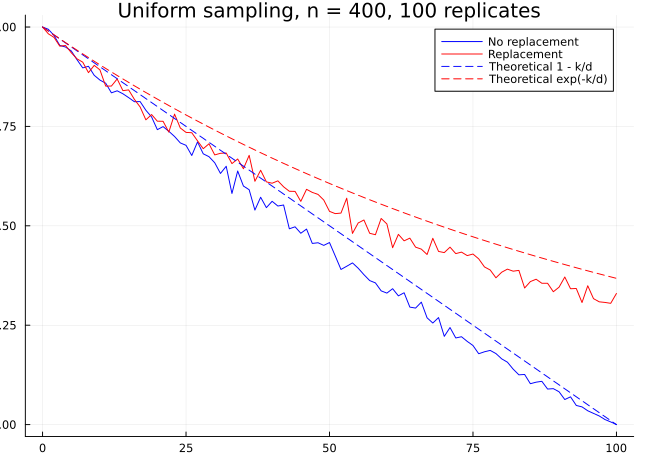

In [1]:
plot(d_range, mses ./ mses[1], xlabel = "Number of parameters", ylabel = "MSE (normalized)", color = :blue,
    label = "No replacement", title = "Uniform sampling, n = 400, 100 replicates")
plot!(d_range, mses_replace ./ mses_replace[1], xlabel = "Number of parameters", color = :red,
    label = "Replacement")
plot!(d_range, (1 .- (d_range) ./ d), color = :blue, linestyle = :dash,
    label = "Theoretical 1 - k/d")
plot!(d_range, exp.(-(d_range) ./ d), color = :red, linestyle = :dash,
    label = "Theoretical exp(-k/d)")

### Experiment 2: Correlated Covariates

In this second experiment, we show that, under moderate correlation, the
mean-squared error of a growing approximation decays much more quickly
than the naive uniform sampling bound might predict. First, let’s
simulate some correlated data.


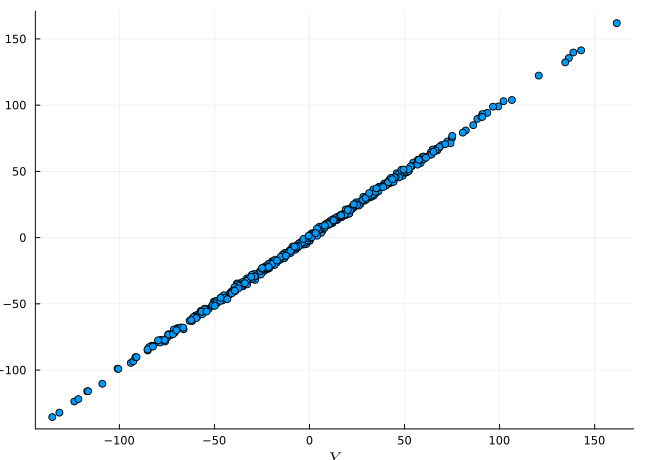

In [1]:
Σ2 = 2 .*  diagm(ones(d)) .+ ones(d,d)

n = 400
ct = rand(scm(Σ2), n)
mat = Tables.matrix(ct)
X = mat[:, 1:end-1]
y = mat[:, end]

# Ground truth
X_design = hcat(ones(n), X)
model = lm(X_design, y)
yhat = GLM.predict(model, X_design)

Plots.scatter(y, yhat, legend = false, xlabel = L"Y", ylabel = L"\hat{Y}")

Next, we will run the same simulation again, but with the new correlated
data.

In [1]:
errs = [[draw_approx(X, y, m; replace = false) for _ in 1:sims] for m in d_range]
errs_replace = [[draw_approx(X, y, m; replace = true) for _ in 1:sims] for m in d_range]

mses = [mean([mse(ym, yhat) for ym in err]) for err in errs]
mses_replace = [mean([mse(ym, yhat) for ym in err]) for err in errs_replace]


101-element Vector{Float64}:
 2433.2981010147455
 1720.253592848394
 1312.765962838647
  984.1551884903395
  866.782200088706
  730.2201035151331
  596.5948911403153
  568.2971374794989
  492.8502226724125
  436.7651348622112
    ⋮
   36.76783301826845
   31.118962993861384
   32.342722775624836
   27.70876223413726
   33.48222489212966
   30.8819369206362
   27.728109832939698
   28.325218430623543
   31.396596175328728

Finally, let’s plot the results again. We can see that, even with only
moderately correlated covariates, the mean-squared error decays much
more rapidly as more and more covariates become included in the model.


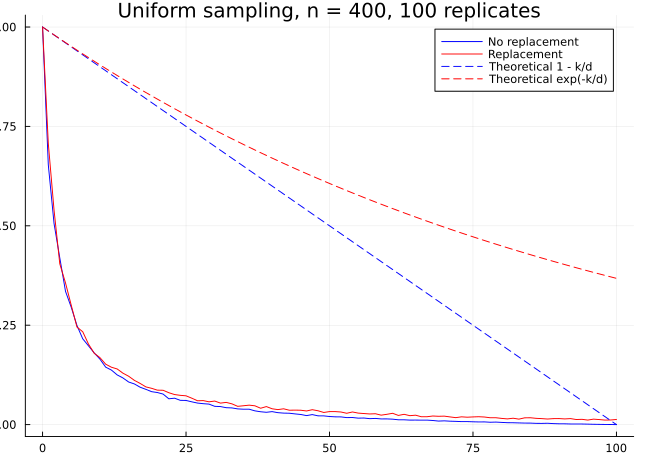

In [1]:
plot(d_range, mses ./ mses[1], xlabel = "Number of parameters", ylabel = "MSE (normalized)", color = :blue,
    label = "No replacement", title = "Uniform sampling, n = 400, 100 replicates")
plot!(d_range, mses_replace ./ mses_replace[1], xlabel = "Number of parameters", color = :red,
    label = "Replacement")
plot!(d_range, (1 .- (d_range) ./ d), color = :blue, linestyle = :dash,
    label = "Theoretical 1 - k/d")
plot!(d_range, exp.(-(d_range) ./ d), color = :red, linestyle = :dash,
    label = "Theoretical exp(-k/d)")